In [558]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper

import joblib # For store the PowerTrasnformers

### Innits


In [516]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [517]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [518]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [5]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    4162
0.022126       1
0.443560       1
0.022259       1
0.598641       1
            ... 
0.063253       1
0.007494       1
0.113382       1
0.010312       1
0.048601       1
Name: count, Length: 2412, dtype: int64


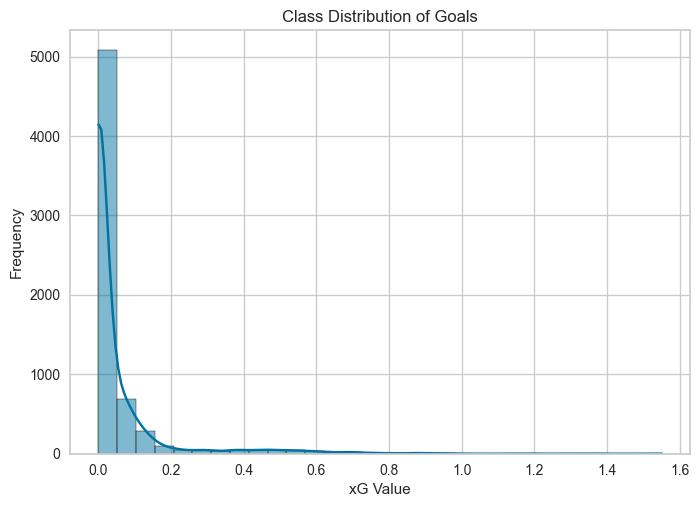

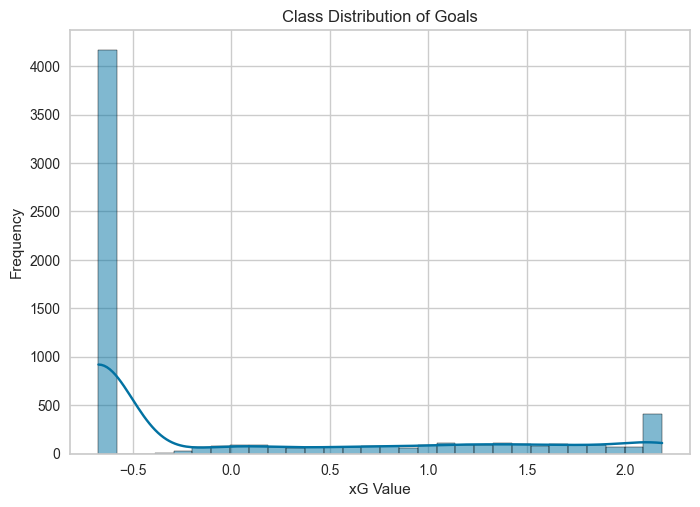

In [565]:

def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xg.fit(def_xg_data[['xG']])
joblib.dump(pt_def_xg, './models/pt_def_xg.pkl')  # Save fitted transformer

def_xg_data['xG'] = pt_def_xg.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [9]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6051
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 88
[LightGBM] [Info] Start training from score -0.005238


,Description,Value
0,Session id,2708
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6573, 147)"
4,Transformed data shape,"(6573, 30)"
5,Transformed train set shape,"(5258, 30)"
6,Transformed test set shape,"(1315, 30)"
7,Numeric features,145
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3184,0.2906,0.5381,0.7049,0.2431,1.5487,2.0150
rf,Random Forest Regressor,0.3198,0.2980,0.5450,0.6973,0.2419,1.6990,3.5750
lightgbm,Light Gradient Boosting Machine,0.3286,0.2992,0.5462,0.6962,0.2456,1.4523,0.8100
gbr,Gradient Boosting Regressor,0.3334,0.2931,0.5404,0.7025,0.2476,1.4430,1.8430
xgboost,Extreme Gradient Boosting,0.3537,0.3249,0.5692,0.6699,0.2512,1.5487,0.8930
ada,AdaBoost Regressor,0.3816,0.3230,0.5678,0.6722,0.2436,1.5987,1.1030
dt,Decision Tree Regressor,0.3892,0.5736,0.7561,0.4176,0.2691,2.2918,0.6750
huber,Huber Regressor,0.4418,0.5060,0.7104,0.4879,0.3248,1.2450,0.7300
knn,K Neighbors Regressor,0.4647,0.4991,0.7055,0.4941,0.3086,1.6474,0.6540
ridge,Ridge Regression,0.5105,0.4653,0.6814,0.5288,0.3510,1.1996,0.8590


ExtraTreesRegressor(n_jobs=-1, random_state=2708)

In [10]:
evaluate_model(base_def_xg_best,)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

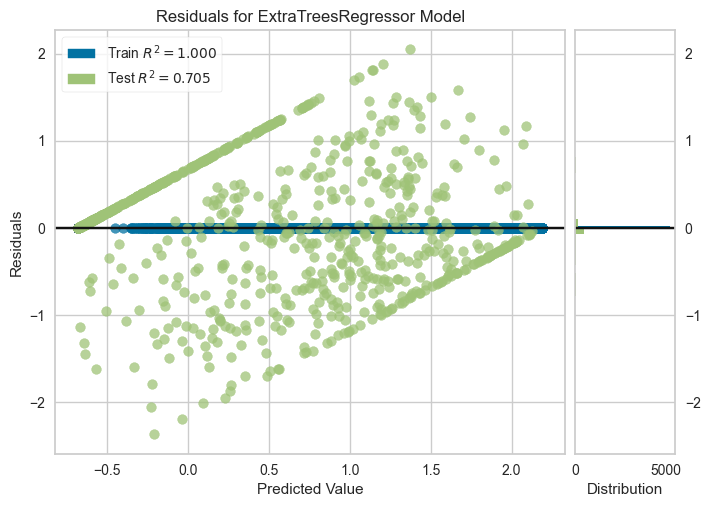

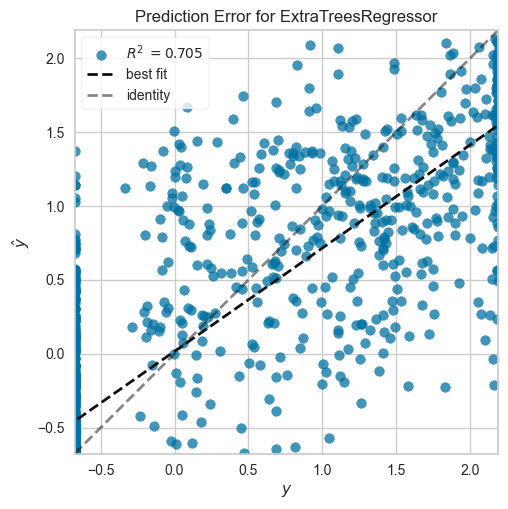

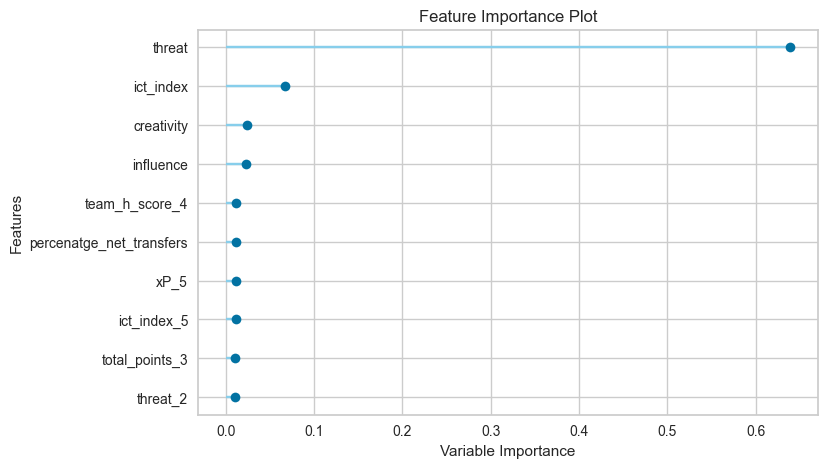

In [11]:
plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Blended Model


In [12]:
blend_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xg_best = compare_models(n_select=3, sort='MAE')
print(def_xg_best)

print('Blended model')
# Ensemble (blend or stack)
def_xg_blended = blend_models(def_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6164
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 88
[LightGBM] [Info] Start training from score 0.002915


,Description,Value
0,Session id,5320
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6573, 147)"
4,Transformed data shape,"(6573, 30)"
5,Transformed train set shape,"(5258, 30)"
6,Transformed test set shape,"(1315, 30)"
7,Numeric features,145
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3228,0.2984,0.5457,0.7013,0.2477,2.0735,3.3650
et,Extra Trees Regressor,0.3250,0.2999,0.5470,0.6994,0.2481,2.1064,1.7530
lightgbm,Light Gradient Boosting Machine,0.3309,0.2993,0.5466,0.7003,0.2470,1.8499,0.8710
gbr,Gradient Boosting Regressor,0.3406,0.3015,0.5486,0.6981,0.2528,2.0329,1.6820
xgboost,Extreme Gradient Boosting,0.3669,0.3392,0.5816,0.6607,0.2571,2.0502,0.7810
ada,AdaBoost Regressor,0.3810,0.3307,0.5747,0.6693,0.2432,2.0245,0.6620
dt,Decision Tree Regressor,0.3972,0.5852,0.7643,0.4146,0.2727,2.3518,0.6050
huber,Huber Regressor,0.4449,0.5174,0.7185,0.4836,0.3274,1.1952,0.5690
knn,K Neighbors Regressor,0.4600,0.4951,0.7028,0.5053,0.3089,1.6321,0.5710
ridge,Ridge Regression,0.5165,0.4762,0.6896,0.5244,0.3551,1.3421,0.7880


[RandomForestRegressor(n_jobs=-1, random_state=5320), ExtraTreesRegressor(n_jobs=-1, random_state=5320), LGBMRegressor(n_jobs=-1, random_state=5320)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3286,0.2872,0.5359,0.7257,0.2514,0.8271
1,0.3254,0.2898,0.5383,0.7007,0.2312,1.1475
2,0.2952,0.2447,0.4947,0.7566,0.2238,1.1716
3,0.3400,0.3289,0.5735,0.6705,0.2575,1.9412
4,0.3213,0.2954,0.5435,0.6789,0.2558,1.3744
5,0.3154,0.2815,0.5306,0.7237,0.2502,5.1450
6,0.3004,0.2657,0.5155,0.7319,0.2379,1.7685
7,0.3162,0.2795,0.5286,0.7423,0.2515,1.0462
8,0.3438,0.3263,0.5712,0.6485,0.2584,3.9325


### Save Model


In [13]:
# # Patch method to prevent column reordering errors
# def _reorder_cols(self, df, original_df):
#     # Just return df without modifying columns
#     return df

# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, './models/def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [17]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    2501
0.761169      11
0.761169       3
0.052510       2
0.423129       1
            ... 
0.103368       1
0.078944       1
0.051074       1
0.104148       1
0.036180       1
Name: count, Length: 4563, dtype: int64


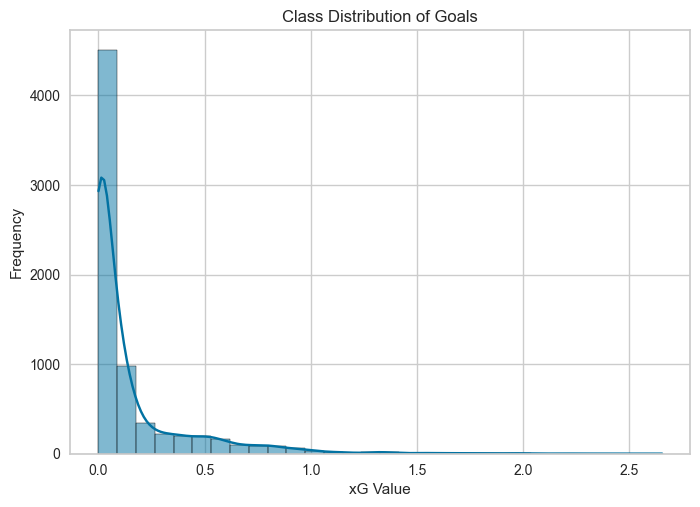

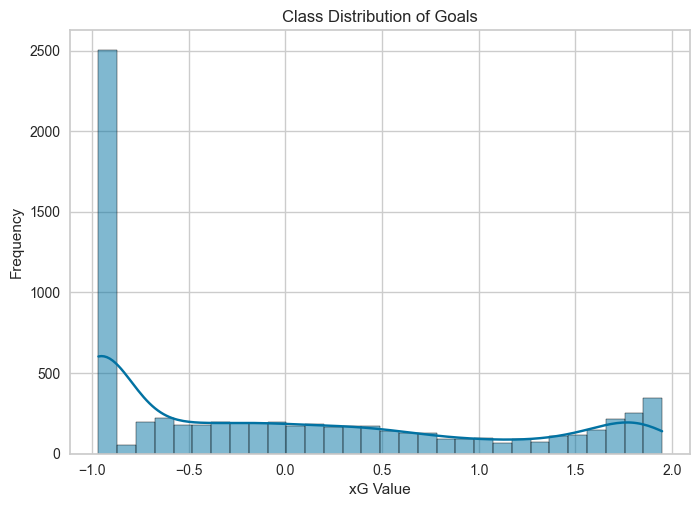

In [563]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xg.fit(mid_xg_data[['xG']])
joblib.dump(pt_mid_xg, './models/pt_mid_xg.pkl')  # Save fitted transformer

mid_xg_data['xG'] = pt_mid_xg.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [21]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE', n_select=1)
base_mid_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008885 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7464
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 82
[LightGBM] [Info] Start training from score 0.000857


,Description,Value
0,Session id,5562
1,Target,xG
2,Target type,Regression
3,Original data shape,"(7076, 147)"
4,Transformed data shape,"(7076, 30)"
5,Transformed train set shape,"(5660, 30)"
6,Transformed test set shape,"(1416, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3633,0.2746,0.5237,0.7258,0.2625,27.1743,5.9710
et,Extra Trees Regressor,0.3652,0.2744,0.5236,0.7260,0.2591,35.2988,2.5450
lightgbm,Light Gradient Boosting Machine,0.3681,0.2776,0.5266,0.7228,0.2604,22.9203,0.8260
gbr,Gradient Boosting Regressor,0.3694,0.2717,0.5209,0.7289,0.2599,29.0777,1.8730
xgboost,Extreme Gradient Boosting,0.3991,0.3110,0.5573,0.6893,0.2699,25.0344,1.0810
ada,AdaBoost Regressor,0.4333,0.3051,0.5520,0.6955,0.2870,30.8829,0.9170
knn,K Neighbors Regressor,0.4641,0.3986,0.6311,0.6019,0.2947,24.7577,0.6070
huber,Huber Regressor,0.4644,0.4091,0.6384,0.5921,0.2925,30.8117,0.8410
dt,Decision Tree Regressor,0.4779,0.5521,0.7424,0.4482,0.3104,42.9882,0.8610
lr,Linear Regression,0.4814,0.3833,0.6183,0.6177,0.3029,21.0961,0.9720


RandomForestRegressor(n_jobs=-1, random_state=5562)

In [22]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

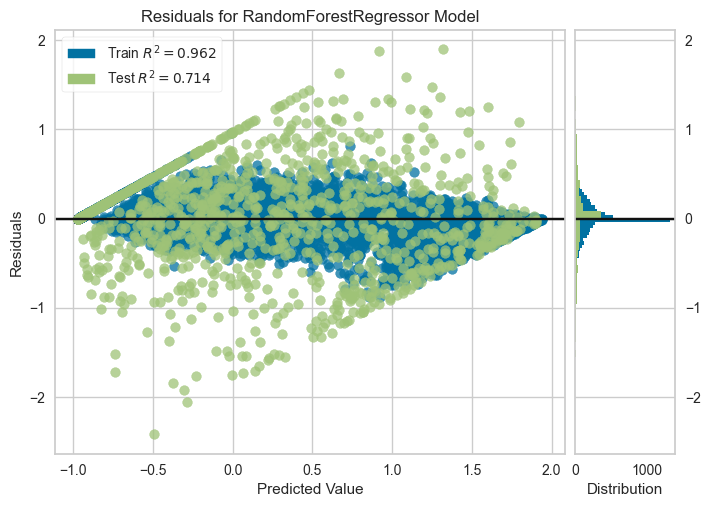

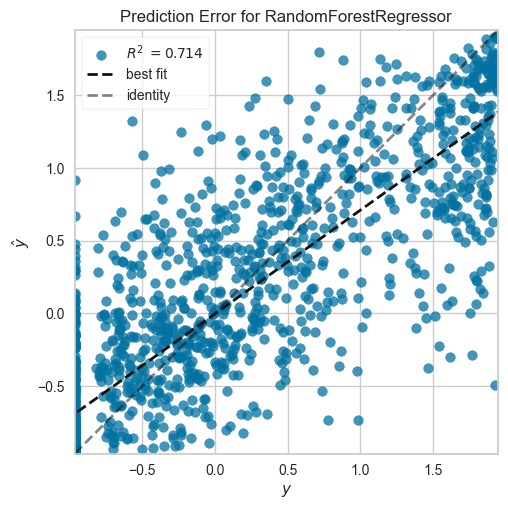

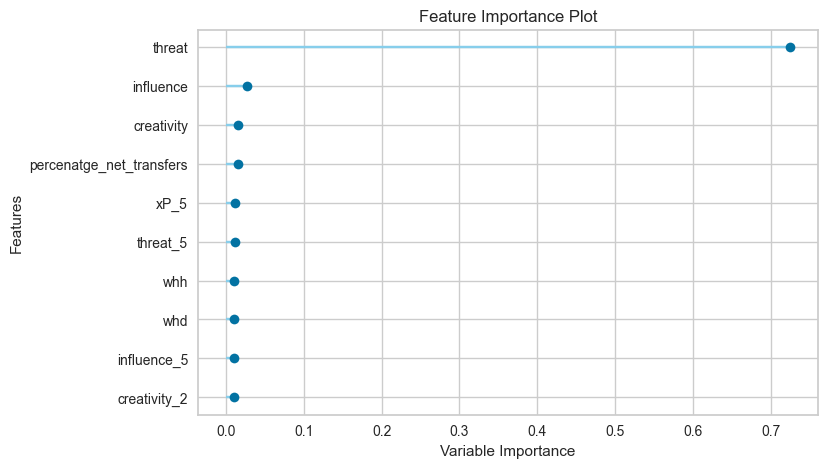

In [23]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Blended Model


In [24]:
blend_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

mid_xg_best = compare_models(n_select=3, sort='MAE')
print(mid_xg_best)

print('Blended model')
# Ensemble (blend or stack)
mid_xg_blended = blend_models(mid_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005852 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7468
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 82
[LightGBM] [Info] Start training from score 0.005500


,Description,Value
0,Session id,1739
1,Target,xG
2,Target type,Regression
3,Original data shape,"(7076, 147)"
4,Transformed data shape,"(7076, 30)"
5,Transformed train set shape,"(5660, 30)"
6,Transformed test set shape,"(1416, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3660,0.2787,0.5275,0.7221,0.2608,24.1325,5.8050
et,Extra Trees Regressor,0.3684,0.2770,0.5258,0.7237,0.2591,26.4782,2.5120
gbr,Gradient Boosting Regressor,0.3696,0.2700,0.5191,0.7308,0.2559,27.5897,1.9610
lightgbm,Light Gradient Boosting Machine,0.3706,0.2797,0.5283,0.7211,0.2587,16.6033,0.9320
xgboost,Extreme Gradient Boosting,0.4001,0.3142,0.5598,0.6869,0.2685,21.8604,0.9810
ada,AdaBoost Regressor,0.4373,0.3087,0.5552,0.6925,0.2856,27.6224,0.8750
knn,K Neighbors Regressor,0.4595,0.3921,0.6256,0.6089,0.2896,25.3026,0.6530
huber,Huber Regressor,0.4662,0.4082,0.6381,0.5938,0.2924,26.5261,0.7820
dt,Decision Tree Regressor,0.4761,0.5337,0.7297,0.4666,0.3096,38.9127,0.9170
lr,Linear Regression,0.4800,0.3819,0.6175,0.6197,0.3011,21.8123,0.9030


[RandomForestRegressor(n_jobs=-1, random_state=1739), ExtraTreesRegressor(n_jobs=-1, random_state=1739), GradientBoostingRegressor(random_state=1739)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3766,0.2818,0.5308,0.7011,0.2663,246.7431
1,0.3494,0.2525,0.5025,0.7291,0.2530,2.4044
2,0.3961,0.3074,0.5545,0.6767,0.2784,1.1483
3,0.3706,0.2686,0.5182,0.7488,0.2661,1.2230
4,0.3945,0.3069,0.5540,0.7315,0.2647,1.8537
5,0.3589,0.2707,0.5203,0.7374,0.2541,1.1384
6,0.3277,0.2263,0.4758,0.7814,0.2380,1.6169
7,0.3705,0.2704,0.5200,0.7263,0.2581,2.0848
8,0.3479,0.2495,0.4995,0.7453,0.2525,1.2129


### Save Model


In [25]:
mid_xg_final_model = finalize_model(mid_xg_blended)
save_model(mid_xg_final_model, './models/mid_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                               

## For


xG
0.000000    290
0.761169      7
0.208655      1
0.582700      1
0.366415      1
           ... 
0.583476      1
0.125661      1
1.442925      1
0.616388      1
0.326243      1
Name: count, Length: 1295, dtype: int64


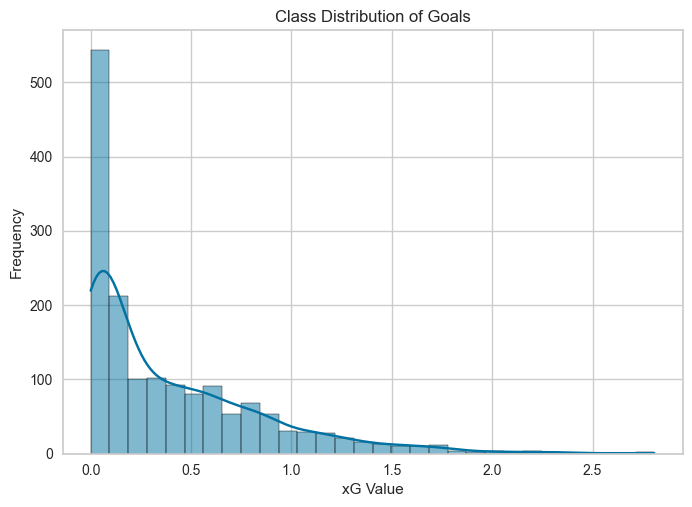

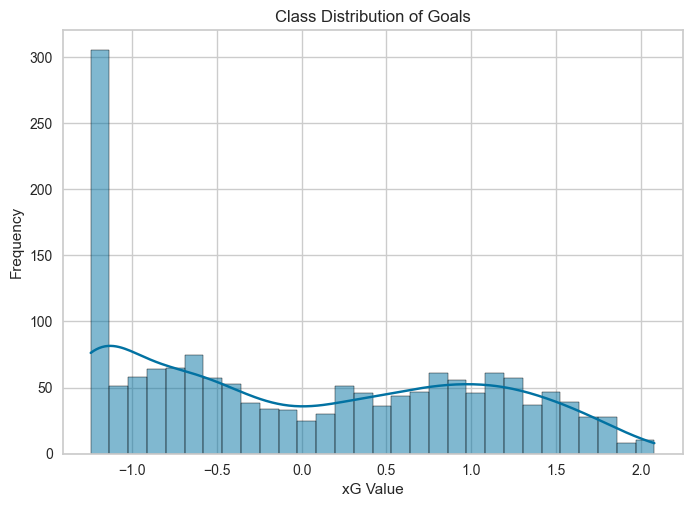

In [564]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xg.fit(fwd_xg_data[['xG']])
joblib.dump(pt_fwd_xg, './models/pt_fwd_xg.pkl')  # Save fitted transformer

fwd_xg_data['xG'] = pt_fwd_xg.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6557
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score -0.010674


,Description,Value
0,Session id,3614
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1590, 147)"
4,Transformed data shape,"(1590, 30)"
5,Transformed train set shape,"(1272, 30)"
6,Transformed test set shape,"(318, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.4372,0.3201,0.5647,0.6711,0.2699,1.2120,0.7270
et,Extra Trees Regressor,0.4420,0.3293,0.5727,0.6617,0.2774,1.2374,0.9120
rf,Random Forest Regressor,0.4435,0.3378,0.5802,0.6525,0.2779,1.2929,1.3420
lightgbm,Light Gradient Boosting Machine,0.4455,0.3397,0.5815,0.6502,0.2700,1.3338,0.6020
xgboost,Extreme Gradient Boosting,0.4657,0.3734,0.6097,0.6153,0.2781,1.3221,0.6090
knn,K Neighbors Regressor,0.4860,0.3938,0.6270,0.5951,0.2914,1.2427,0.3540
huber,Huber Regressor,0.5012,0.4070,0.6360,0.5819,0.2843,1.2834,0.3430
lr,Linear Regression,0.5034,0.3783,0.6136,0.6110,0.2932,1.1716,0.3280
ridge,Ridge Regression,0.5035,0.3781,0.6134,0.6112,0.2936,1.1733,0.3740
br,Bayesian Ridge,0.5074,0.3835,0.6178,0.6061,0.2956,1.1638,0.4270


GradientBoostingRegressor(random_state=3614)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


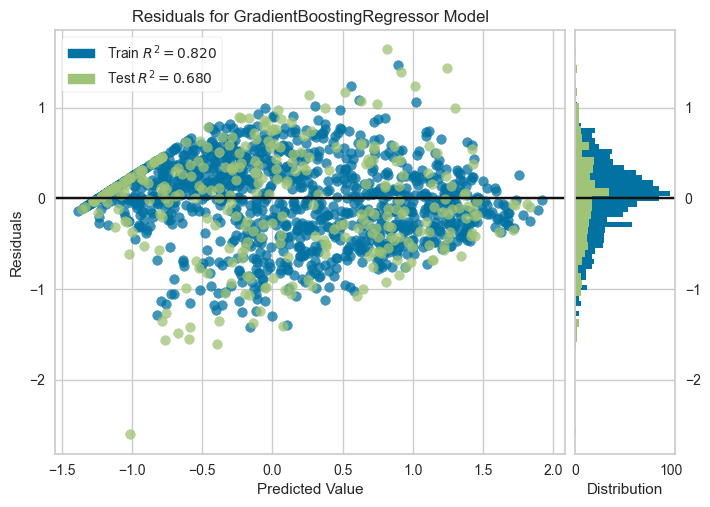

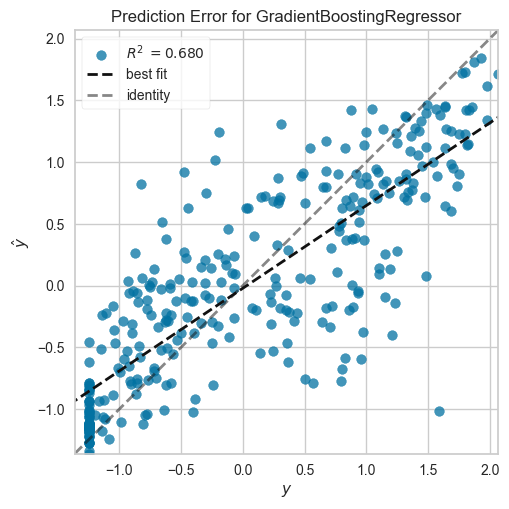

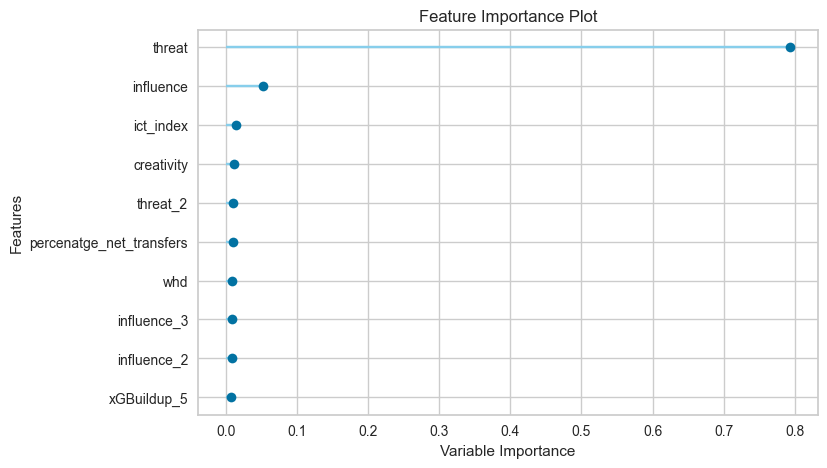

In [27]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Blended Model


In [28]:
blend_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

fwd_xg_best = compare_models(n_select=3, sort='MAE')
print(fwd_xg_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_xg_blended = blend_models(fwd_xg_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001398 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5963
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 79
[LightGBM] [Info] Start training from score -0.027300


,Description,Value
0,Session id,3781
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1590, 147)"
4,Transformed data shape,"(1590, 30)"
5,Transformed train set shape,"(1272, 30)"
6,Transformed test set shape,"(318, 30)"
7,Numeric features,145
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.4418,0.3277,0.5706,0.6702,0.2748,1.2505,0.6300
rf,Random Forest Regressor,0.4479,0.3447,0.5852,0.6532,0.2736,1.2402,1.3900
et,Extra Trees Regressor,0.4558,0.3493,0.5894,0.6482,0.2776,1.2448,0.8320
lightgbm,Light Gradient Boosting Machine,0.4594,0.3567,0.5950,0.6417,0.2691,1.3232,0.4740
xgboost,Extreme Gradient Boosting,0.4710,0.3851,0.6184,0.6125,0.2747,1.3888,0.7220
knn,K Neighbors Regressor,0.5024,0.4315,0.6552,0.5638,0.2907,1.1953,0.3710
huber,Huber Regressor,0.5034,0.4172,0.6444,0.5786,0.2868,1.2620,0.4760
lr,Linear Regression,0.5044,0.3868,0.6205,0.6104,0.2935,1.1502,0.5100
ridge,Ridge Regression,0.5046,0.3860,0.6199,0.6111,0.2938,1.1526,0.3540
br,Bayesian Ridge,0.5102,0.3903,0.6233,0.6066,0.2956,1.1404,0.3090


[GradientBoostingRegressor(random_state=3781), RandomForestRegressor(n_jobs=-1, random_state=3781), ExtraTreesRegressor(n_jobs=-1, random_state=3781)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4007,0.2864,0.5351,0.7180,0.2583,2.3960
1,0.4106,0.2687,0.5184,0.7181,0.2807,1.3759
2,0.4794,0.4098,0.6402,0.6240,0.2736,0.7202
3,0.4260,0.2913,0.5398,0.7075,0.2781,0.6996
4,0.4037,0.2814,0.5304,0.7137,0.2544,1.1017
5,0.4600,0.3541,0.5950,0.6645,0.2749,1.4860
6,0.5061,0.4198,0.6479,0.5669,0.3101,1.2137
7,0.4705,0.3557,0.5964,0.6522,0.2767,1.0132
8,0.4712,0.3698,0.6081,0.6043,0.2548,0.8910


### Save Model


In [29]:
fwd_xg_final_model = finalize_model(base_fwd_xg_best)
save_model(fwd_xg_final_model, './models/fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# Assists


In [30]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'shots_2', 'xA_2', 'assists_x_2',
            'assists_y_2',
            'key_passes_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4',  'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'shots_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    4470
0.059942       2
0.063347       1
0.108050       1
0.049833       1
            ... 
0.016065       1
0.037171       1
0.023500       1
0.013137       1
0.549479       1
Name: count, Length: 2103, dtype: int64


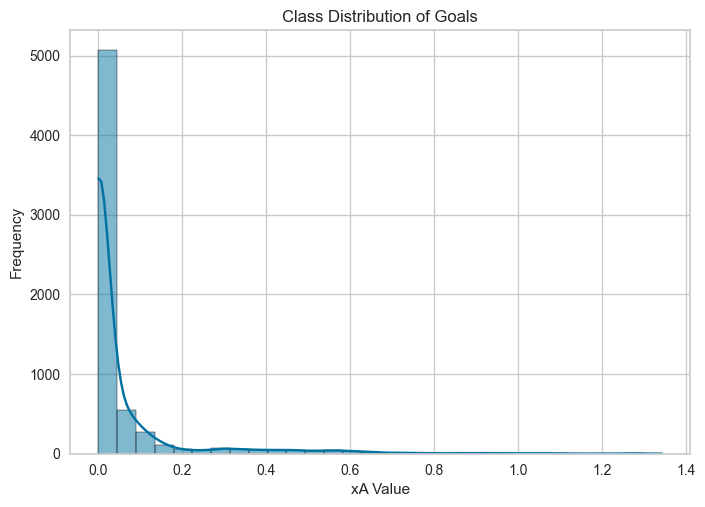

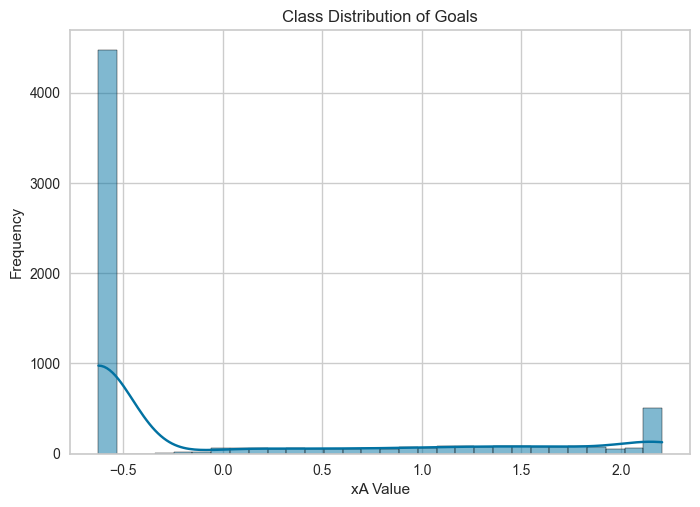

In [566]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xa.fit(def_xa_data[['xA']])
joblib.dump(pt_def_xa, './models/pt_def_xa.pkl')  # Save fitted transformer

def_xa_data['xA'] = pt_def_xa.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007466 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6057
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 78
[LightGBM] [Info] Start training from score -0.005888


,Description,Value
0,Session id,5366
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6573, 118)"
4,Transformed data shape,"(6573, 24)"
5,Transformed train set shape,"(5258, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,116
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.1962,0.1772,0.4204,0.8210,0.1875,0.9989,3.2650
et,Extra Trees Regressor,0.1999,0.1752,0.4182,0.8229,0.1891,0.9923,1.3600
gbr,Gradient Boosting Regressor,0.2024,0.1728,0.4151,0.8254,0.1861,1.0383,1.4180
ada,AdaBoost Regressor,0.2062,0.1765,0.4195,0.8218,0.1895,1.0009,0.7630
lightgbm,Light Gradient Boosting Machine,0.2083,0.1841,0.4286,0.8141,0.1960,0.9857,0.8260
xgboost,Extreme Gradient Boosting,0.2277,0.2085,0.4562,0.7895,0.2046,1.0121,0.7110
knn,K Neighbors Regressor,0.2495,0.2549,0.5043,0.7435,0.2287,0.9772,0.4550
dt,Decision Tree Regressor,0.2503,0.3312,0.5738,0.6656,0.2527,1.0966,0.5490
huber,Huber Regressor,0.3354,0.3815,0.6155,0.6166,0.2849,0.6197,0.6620
ridge,Ridge Regression,0.3922,0.3618,0.5998,0.6362,0.2879,0.7494,0.3820


RandomForestRegressor(n_jobs=-1, random_state=5366)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


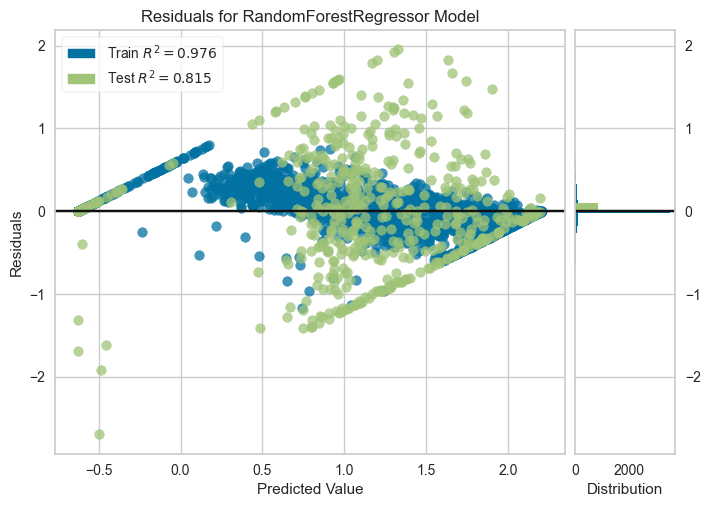

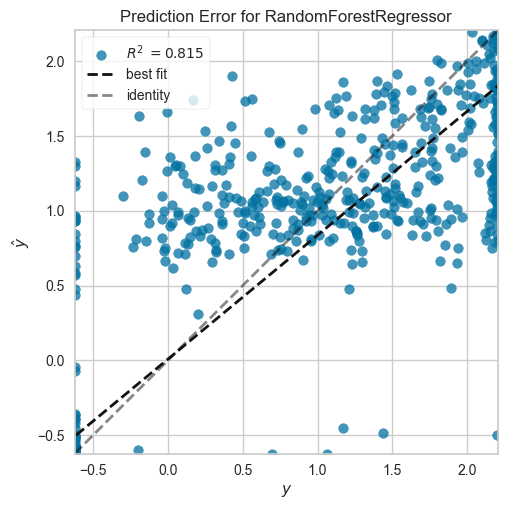

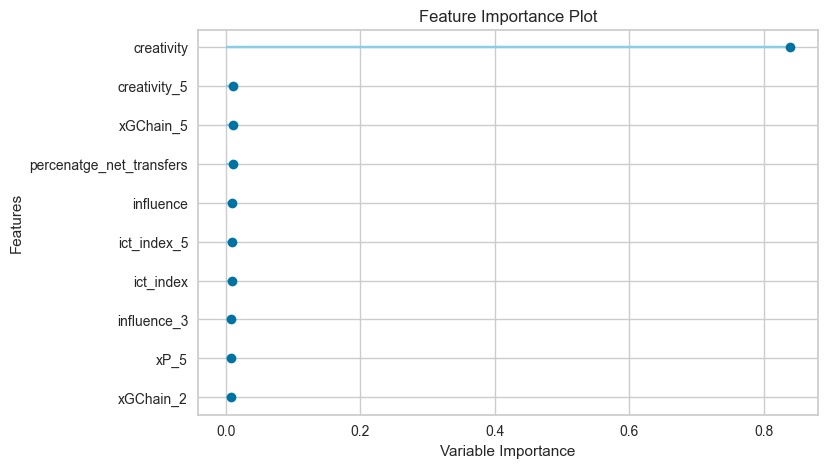

In [32]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Blended Model


In [33]:
blend_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xa_best = compare_models(n_select=3, sort='MAE')
print(def_xa_best)

print('Blended model')
# Ensemble (blend or stack)
def_xa_blended = blend_models(def_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001566 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6232
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 79
[LightGBM] [Info] Start training from score 0.007398


,Description,Value
0,Session id,1024
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6573, 118)"
4,Transformed data shape,"(6573, 24)"
5,Transformed train set shape,"(5258, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,116
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.2025,0.1824,0.4262,0.8198,0.1875,0.8854,3.9920
et,Extra Trees Regressor,0.2045,0.1790,0.4222,0.8232,0.1879,0.8685,2.8840
gbr,Gradient Boosting Regressor,0.2088,0.1779,0.4211,0.8241,0.1866,0.8852,2.2470
ada,AdaBoost Regressor,0.2131,0.1865,0.4311,0.8157,0.1896,0.9089,2.9720
lightgbm,Light Gradient Boosting Machine,0.2132,0.1878,0.4321,0.8146,0.1936,0.8828,1.4590
xgboost,Extreme Gradient Boosting,0.2327,0.2129,0.4605,0.7896,0.2038,0.9233,1.4180
knn,K Neighbors Regressor,0.2621,0.2732,0.5214,0.7302,0.2371,0.8443,0.7390
dt,Decision Tree Regressor,0.2728,0.3746,0.6106,0.6299,0.2581,0.9253,0.7610
huber,Huber Regressor,0.3413,0.3978,0.6296,0.6061,0.2859,0.5587,0.6600
lr,Linear Regression,0.4033,0.3786,0.6146,0.6249,0.2922,0.6977,0.8030


[RandomForestRegressor(n_jobs=-1, random_state=1024), ExtraTreesRegressor(n_jobs=-1, random_state=1024), GradientBoostingRegressor(random_state=1024)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1956,0.1734,0.4165,0.8309,0.1839,0.6294
1,0.2418,0.2057,0.4535,0.8126,0.1997,0.7550
2,0.2064,0.1986,0.4456,0.8052,0.1698,0.5807
3,0.2089,0.1786,0.4226,0.8216,0.1873,1.1223
4,0.2176,0.1731,0.4161,0.8367,0.1929,1.4716
5,0.1883,0.1689,0.4109,0.8220,0.1778,0.4815
6,0.2095,0.1819,0.4265,0.8239,0.2019,0.9103
7,0.1579,0.1282,0.3580,0.8562,0.1614,0.5408
8,0.1858,0.1585,0.3981,0.8324,0.1841,1.0637


### Save Model


In [34]:
def_xa_final_model = finalize_model(def_xa_blended)
save_model(def_xa_final_model, './models/def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                              

## Mid


xA
0.000000    2859
0.107738       2
0.095407       1
0.023504       1
0.403232       1
            ... 
0.454983       1
0.081762       1
0.106337       1
0.115025       1
0.043413       1
Name: count, Length: 4217, dtype: int64


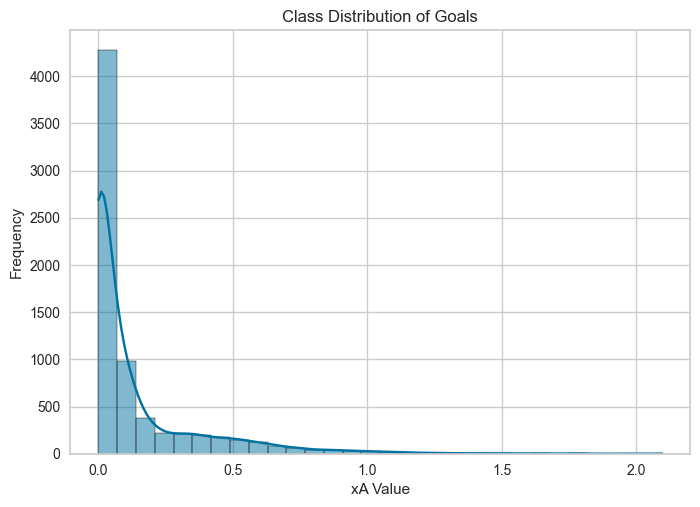

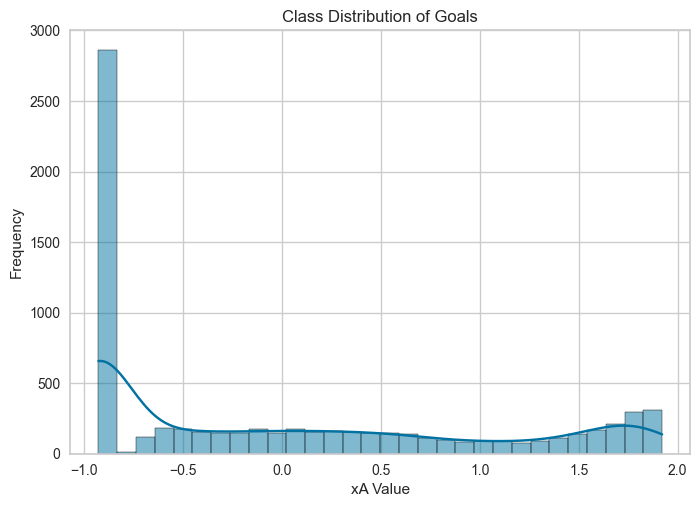

In [567]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xa.fit(mid_xa_data[['xA']])
joblib.dump(pt_mid_xa, './models/pt_mid_xa.pkl')  # Save fitted transformer

mid_xa_data['xA'] = pt_mid_xa.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006006 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7350
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 76
[LightGBM] [Info] Start training from score 0.001202


,Description,Value
0,Session id,1254
1,Target,xA
2,Target type,Regression
3,Original data shape,"(7076, 118)"
4,Transformed data shape,"(7076, 24)"
5,Transformed train set shape,"(5660, 24)"
6,Transformed test set shape,"(1416, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3428,0.2891,0.5372,0.7111,0.2620,1.5703,5.2900
et,Extra Trees Regressor,0.3511,0.2923,0.5403,0.7079,0.2672,1.5726,3.2710
gbr,Gradient Boosting Regressor,0.3523,0.2857,0.5341,0.7145,0.2729,1.4274,3.3810
lightgbm,Light Gradient Boosting Machine,0.3525,0.2914,0.5395,0.7087,0.2649,1.5145,3.2580
xgboost,Extreme Gradient Boosting,0.3848,0.3254,0.5701,0.6746,0.2705,1.6552,2.5840
ada,AdaBoost Regressor,0.3953,0.3159,0.5617,0.6844,0.2467,1.7853,1.9740
knn,K Neighbors Regressor,0.4231,0.3911,0.6251,0.6089,0.2883,1.8266,1.2460
huber,Huber Regressor,0.4308,0.4154,0.6439,0.5849,0.2961,1.2944,1.6880
dt,Decision Tree Regressor,0.4471,0.5455,0.7378,0.4538,0.3141,2.4089,0.8960
lr,Linear Regression,0.4633,0.3910,0.6249,0.6092,0.3103,1.2726,1.1510


RandomForestRegressor(n_jobs=-1, random_state=1254)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


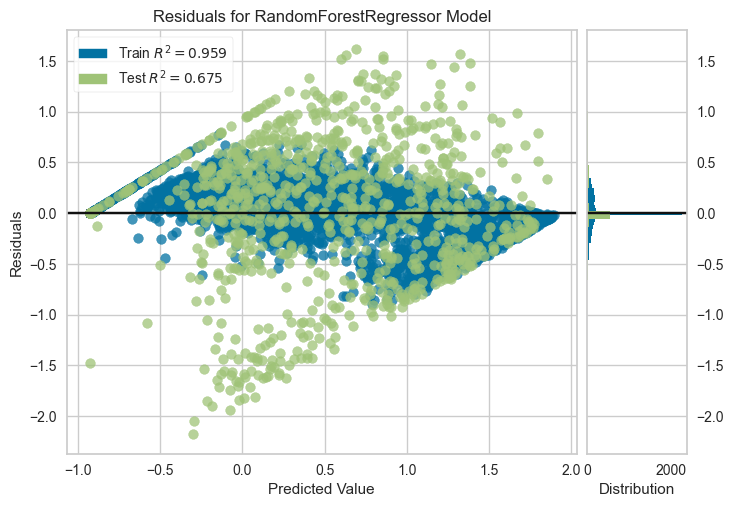

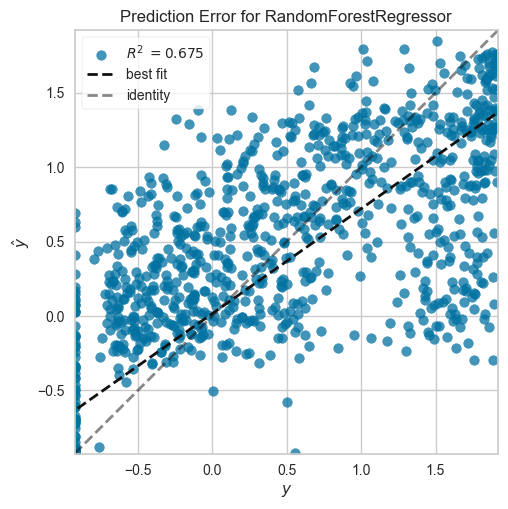

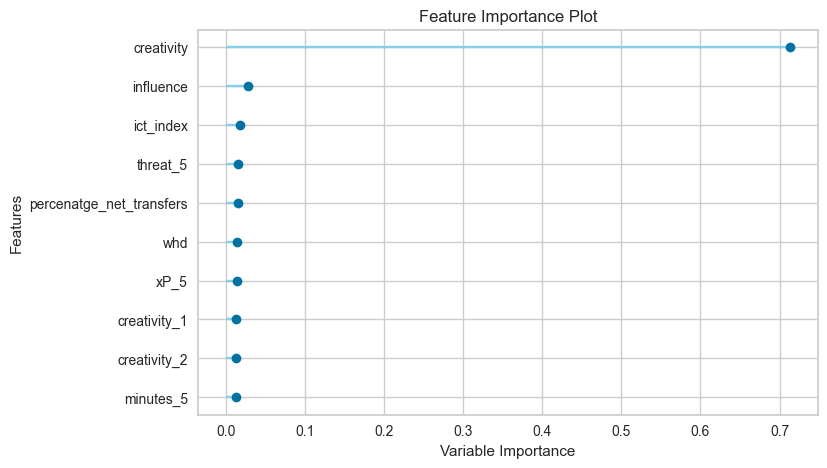

In [36]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Blended model


In [37]:
blend_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

mid_xa_best = compare_models(n_select=3, sort='MAE')
print(mid_xa_best)

print('Blended model')
# Ensemble (blend or stack)
mid_xa_blended = blend_models(mid_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7504
[LightGBM] [Info] Number of data points in the train set: 5660, number of used features: 76
[LightGBM] [Info] Start training from score 0.008443


,Description,Value
0,Session id,6253
1,Target,xA
2,Target type,Regression
3,Original data shape,"(7076, 118)"
4,Transformed data shape,"(7076, 24)"
5,Transformed train set shape,"(5660, 24)"
6,Transformed test set shape,"(1416, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3482,0.2964,0.5442,0.7062,0.2651,1.4206,5.2820
et,Extra Trees Regressor,0.3539,0.2974,0.5450,0.7052,0.2669,1.4414,2.8870
gbr,Gradient Boosting Regressor,0.3555,0.2913,0.5393,0.7113,0.2738,1.3430,3.1060
lightgbm,Light Gradient Boosting Machine,0.3577,0.2989,0.5465,0.7035,0.2668,1.3986,2.3240
ada,AdaBoost Regressor,0.3870,0.3173,0.5631,0.6852,0.2484,1.6961,1.0860
xgboost,Extreme Gradient Boosting,0.3915,0.3324,0.5762,0.6705,0.2721,1.5194,2.1050
knn,K Neighbors Regressor,0.4307,0.4068,0.6372,0.5969,0.2892,1.5570,1.5220
huber,Huber Regressor,0.4362,0.4282,0.6531,0.5762,0.3000,1.1442,1.8320
dt,Decision Tree Regressor,0.4556,0.5737,0.7565,0.4315,0.3108,2.3585,1.3600
lr,Linear Regression,0.4718,0.4042,0.6349,0.5996,0.3157,1.1601,1.5250


[RandomForestRegressor(n_jobs=-1, random_state=6253), ExtraTreesRegressor(n_jobs=-1, random_state=6253), GradientBoostingRegressor(random_state=6253)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3423,0.2730,0.5225,0.7251,0.2579,1.4477
1,0.3404,0.2795,0.5287,0.6999,0.2546,1.7854
2,0.3445,0.2732,0.5227,0.7182,0.2624,1.4251
3,0.3520,0.2930,0.5413,0.7127,0.2642,1.7206
4,0.3550,0.3089,0.5558,0.7052,0.2831,1.1969
5,0.3866,0.3382,0.5815,0.6906,0.2896,0.9965
6,0.3519,0.2936,0.5418,0.7097,0.2694,1.2723
7,0.3349,0.2705,0.5201,0.7198,0.2639,1.0861
8,0.3418,0.2725,0.5220,0.7348,0.2602,1.0307


### Save Model


In [38]:
mid_xa_final_model = finalize_model(mid_xa_blended)
save_model(mid_xa_final_model, './models/mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SelectFromModel(estimator=LGBMRegressor(),
                                              

## For


xA
0.000000    767
0.127663      1
0.077458      1
0.147103      1
0.733360      1
           ... 
0.414716      1
0.122116      1
0.031267      1
0.401950      1
0.048869      1
Name: count, Length: 824, dtype: int64


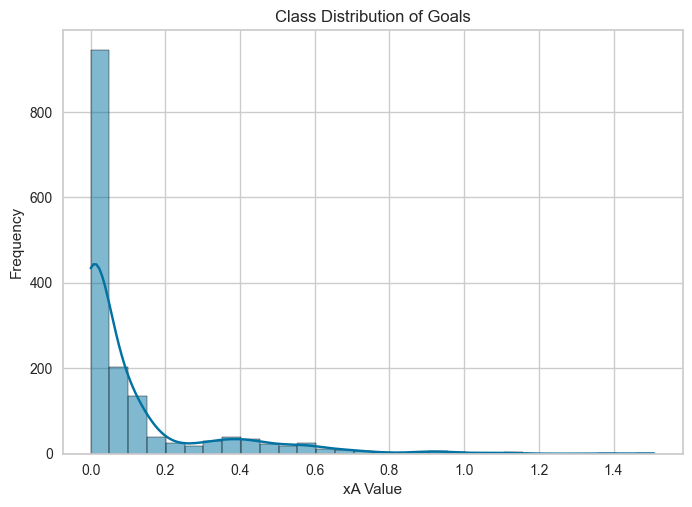

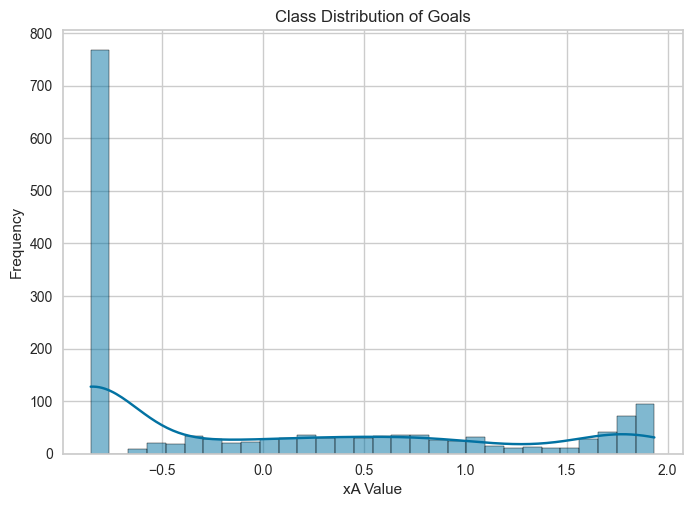

In [568]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xa.fit(fwd_xa_data[['xA']])
joblib.dump(pt_fwd_xa, './models/pt_fwd_xa.pkl')  # Save fitted transformer

fwd_xa_data['xA'] = pt_fwd_xa.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7225
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 82
[LightGBM] [Info] Start training from score 0.004114


,Description,Value
0,Session id,3056
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1590, 118)"
4,Transformed data shape,"(1590, 24)"
5,Transformed train set shape,"(1272, 24)"
6,Transformed test set shape,"(318, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3187,0.2711,0.5189,0.7228,0.2342,1.0556,3.9670
rf,Random Forest Regressor,0.3216,0.2777,0.5250,0.7165,0.2361,1.1199,4.0070
gbr,Gradient Boosting Regressor,0.3382,0.2790,0.5265,0.7154,0.2364,1.0521,3.6010
lightgbm,Light Gradient Boosting Machine,0.3505,0.2963,0.5426,0.6970,0.2522,1.1674,1.2800
xgboost,Extreme Gradient Boosting,0.3575,0.3249,0.5685,0.6673,0.2623,1.2118,1.4400
dt,Decision Tree Regressor,0.3927,0.4891,0.6969,0.4968,0.2933,1.4596,0.7220
huber,Huber Regressor,0.4189,0.3906,0.6212,0.6025,0.2970,0.8280,0.9550
br,Bayesian Ridge,0.4393,0.3669,0.6029,0.6257,0.3065,0.8407,2.9260
ridge,Ridge Regression,0.4395,0.3699,0.6054,0.6225,0.3059,0.8491,0.8220
lr,Linear Regression,0.4404,0.3708,0.6062,0.6215,0.3060,0.8519,1.2190


ExtraTreesRegressor(n_jobs=-1, random_state=3056)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


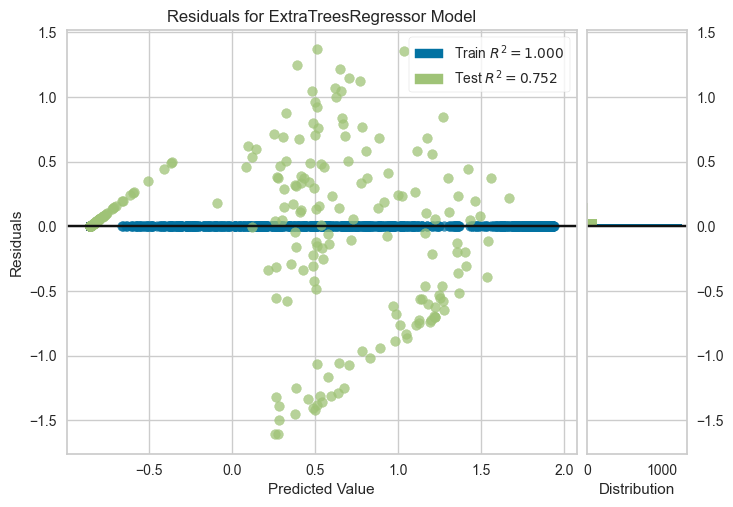

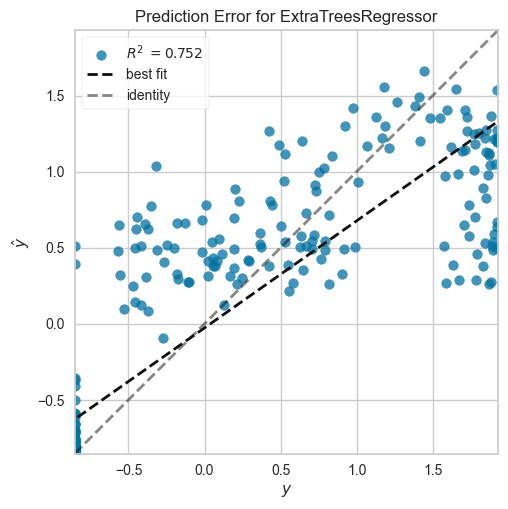

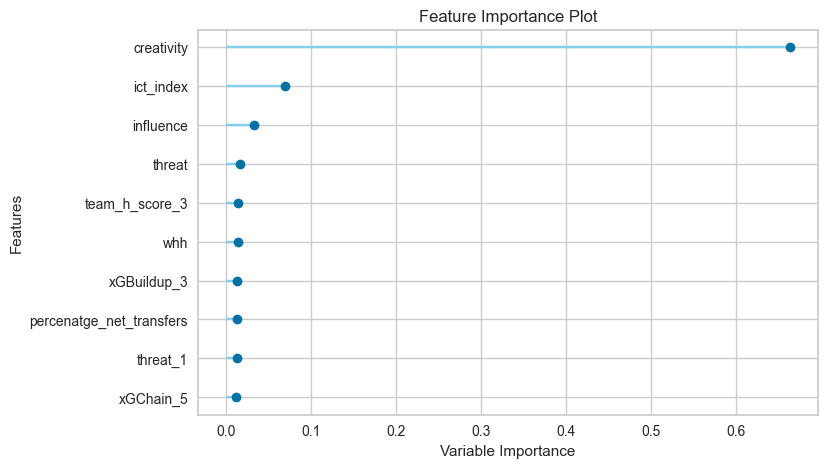

In [40]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Blended model


In [41]:
blend_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

fwd_xa_best = compare_models(n_select=3, sort='MAE')
print(fwd_xa_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_xa_blended = blend_models(fwd_xa_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.463109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7063
[LightGBM] [Info] Number of data points in the train set: 1272, number of used features: 81
[LightGBM] [Info] Start training from score -0.008706
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Description,Value
0,Session id,6748
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1590, 118)"
4,Transformed data shape,"(1590, 24)"
5,Transformed train set shape,"(1272, 24)"
6,Transformed test set shape,"(318, 24)"
7,Numeric features,116
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3143,0.2723,0.5201,0.7228,0.2351,1.0961,1.6130
et,Extra Trees Regressor,0.3204,0.2747,0.5220,0.7209,0.2334,1.0907,0.7480
gbr,Gradient Boosting Regressor,0.3333,0.2832,0.5309,0.7121,0.2401,1.1236,0.7250
lightgbm,Light Gradient Boosting Machine,0.3432,0.2964,0.5429,0.6983,0.2477,1.2213,0.9300
xgboost,Extreme Gradient Boosting,0.3596,0.3277,0.5700,0.6664,0.2587,1.2820,0.6880
dt,Decision Tree Regressor,0.4027,0.5085,0.7104,0.4844,0.2938,1.4647,0.4930
huber,Huber Regressor,0.4088,0.3861,0.6191,0.6085,0.2973,0.7544,0.4690
ada,AdaBoost Regressor,0.4189,0.3103,0.5542,0.6845,0.2430,1.3018,0.4680
br,Bayesian Ridge,0.4313,0.3672,0.6044,0.6276,0.3057,0.8197,2.1770
ridge,Ridge Regression,0.4341,0.3736,0.6097,0.6210,0.3060,0.8404,2.3950


[RandomForestRegressor(n_jobs=-1, random_state=6748), ExtraTreesRegressor(n_jobs=-1, random_state=6748), GradientBoostingRegressor(random_state=6748)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3468,0.3416,0.5845,0.6618,0.2403,1.2833
1,0.3275,0.2808,0.5299,0.7446,0.2552,0.5623
2,0.3488,0.3146,0.5609,0.6400,0.2211,1.5742
3,0.3424,0.2896,0.5381,0.7275,0.2605,1.6881
4,0.2823,0.2119,0.4603,0.7752,0.2153,1.1648
5,0.3134,0.2589,0.5088,0.7381,0.2279,0.8346
6,0.2753,0.2058,0.4537,0.7733,0.1978,0.6934
7,0.2927,0.2195,0.4685,0.7700,0.2289,0.9475
8,0.3357,0.3024,0.5499,0.6789,0.2317,0.9027


### Save Model


In [42]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, './models/fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2     360
3     298
1     255
4     235
5     156
0     126
6      84
7      54
8      21
9      15
10      4
11      2
12      1
13      1
Name: count, dtype: int64


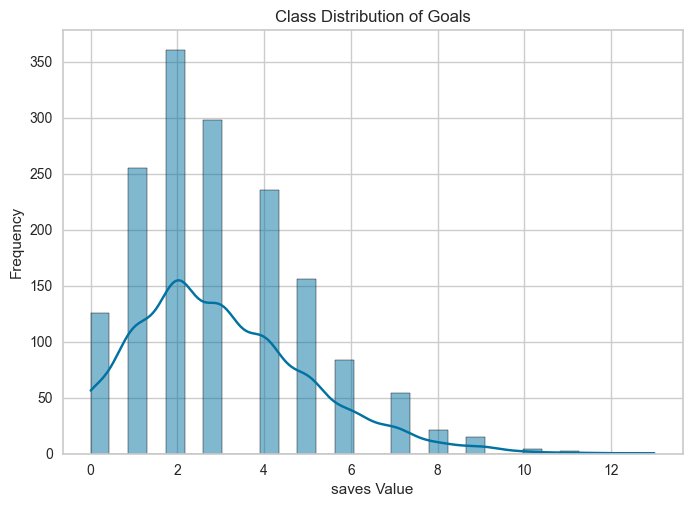

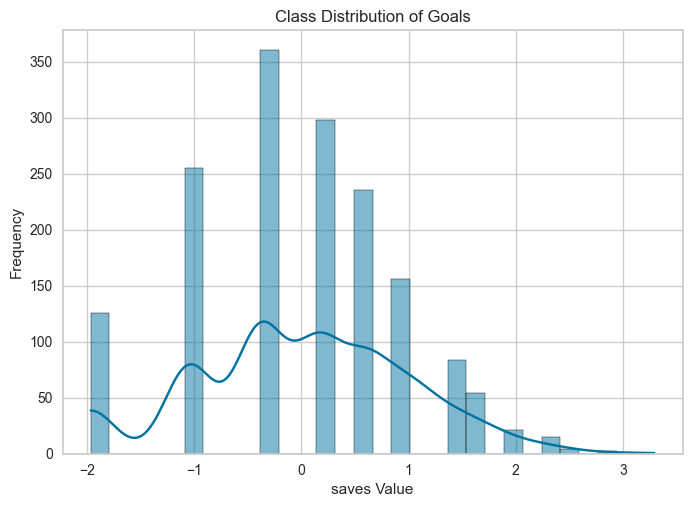

In [569]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_saves = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_saves.fit(g_saves_data[['saves']])
joblib.dump(pt_gk_saves, './models/pt_gk_saves.pkl')  # Save fitted transformer

g_saves_data['saves'] = pt_gk_saves.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002560 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3002
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 65
[LightGBM] [Info] Start training from score -0.004107


,Description,Value
0,Session id,8052
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(1612, 24)"
5,Transformed train set shape,"(1289, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2721,0.1439,0.3776,0.8526,0.1865,0.6318,1.2230
rf,Random Forest Regressor,0.2749,0.1478,0.3825,0.8488,0.1909,0.6302,2.0760
et,Extra Trees Regressor,0.2816,0.1469,0.3819,0.8493,0.1909,0.6518,2.2250
lightgbm,Light Gradient Boosting Machine,0.2846,0.1546,0.3912,0.8414,0.1966,0.6654,1.4910
xgboost,Extreme Gradient Boosting,0.3026,0.1741,0.4160,0.8220,0.2072,0.7087,1.3160
br,Bayesian Ridge,0.3156,0.1847,0.4284,0.8125,0.2008,0.6923,0.2190
omp,Orthogonal Matching Pursuit,0.3164,0.1872,0.4312,0.8097,0.2007,0.6926,0.3580
ridge,Ridge Regression,0.3175,0.1855,0.4292,0.8117,0.2027,0.6991,0.3140
lr,Linear Regression,0.3178,0.1856,0.4293,0.8116,0.2029,0.6996,0.3230
en,Elastic Net,0.3203,0.1885,0.4327,0.8087,0.2035,0.6826,0.2620


GradientBoostingRegressor(random_state=8052)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


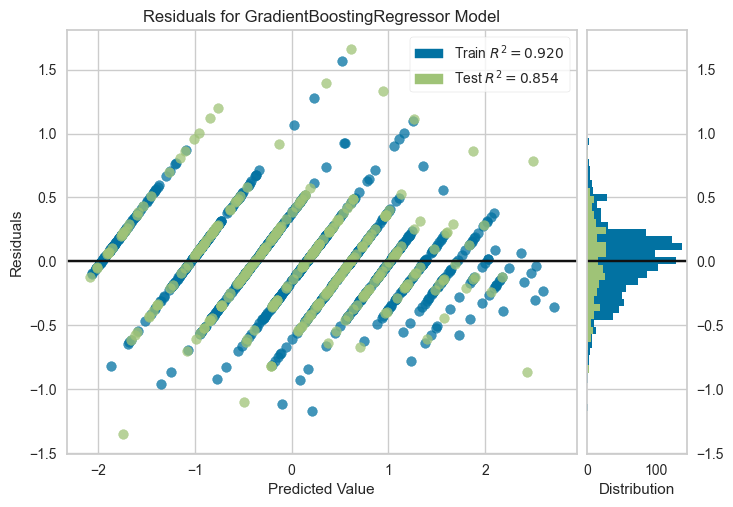

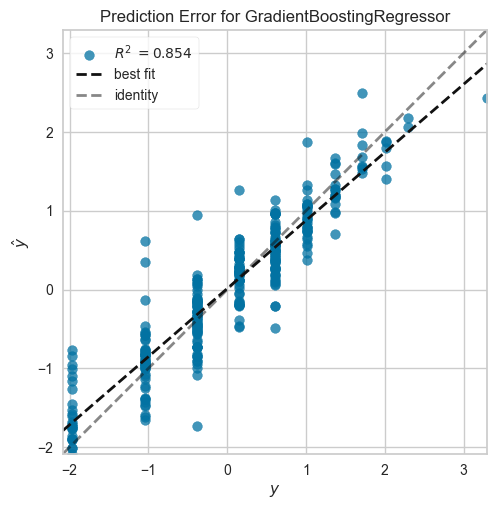

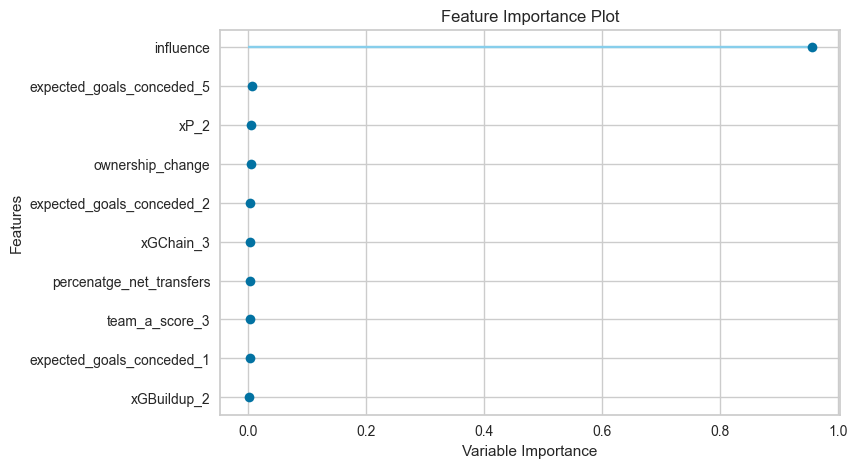

In [44]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Blended Model


In [45]:
blend_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

g_saves_best = compare_models(n_select=3, sort='MAE')
print(g_saves_best)

print('Blended model')
# Ensemble (blend or stack)
g_saves_blended = blend_models(g_saves_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007851 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2991
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 65
[LightGBM] [Info] Start training from score -0.027925


,Description,Value
0,Session id,4386
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(1612, 24)"
5,Transformed train set shape,"(1289, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.2811,0.1502,0.3856,0.8465,0.1907,0.6339,0.7020
rf,Random Forest Regressor,0.2828,0.1531,0.3894,0.8430,0.1931,0.6440,1.6120
et,Extra Trees Regressor,0.2857,0.1527,0.3888,0.8439,0.1928,0.6461,0.8270
lightgbm,Light Gradient Boosting Machine,0.2940,0.1616,0.4006,0.8342,0.2011,0.6736,1.8640
xgboost,Extreme Gradient Boosting,0.3067,0.1784,0.4208,0.8167,0.2100,0.7085,1.1970
br,Bayesian Ridge,0.3148,0.1838,0.4272,0.8119,0.2041,0.6724,1.5320
omp,Orthogonal Matching Pursuit,0.3156,0.1851,0.4288,0.8104,0.2034,0.6748,2.4490
ridge,Ridge Regression,0.3166,0.1848,0.4282,0.8110,0.2062,0.6745,1.3900
lr,Linear Regression,0.3169,0.1850,0.4284,0.8109,0.2065,0.6747,2.0260
en,Elastic Net,0.3192,0.1864,0.4304,0.8093,0.2061,0.6648,1.8280


[GradientBoostingRegressor(random_state=4386), RandomForestRegressor(n_jobs=-1, random_state=4386), ExtraTreesRegressor(n_jobs=-1, random_state=4386)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2868,0.1644,0.4055,0.8316,0.1949,0.7413
1,0.3064,0.2057,0.4535,0.8009,0.2283,0.8106
2,0.2621,0.1231,0.3509,0.8767,0.1865,0.6359
3,0.2821,0.1314,0.3624,0.8193,0.1855,0.6655
4,0.2607,0.1308,0.3617,0.8575,0.1712,0.5674
5,0.3042,0.2064,0.4544,0.7990,0.2027,0.6097
6,0.2628,0.1266,0.3558,0.8795,0.1944,0.6403
7,0.2749,0.1294,0.3597,0.8825,0.1716,0.5047
8,0.2796,0.1298,0.3603,0.8818,0.1826,0.5560


### Save Model


In [46]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, './models/g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [47]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

## GK


expected_goals_conceded
1.48    19
0.83    17
1.03    14
1.32    13
1.12    13
        ..
3.22     1
2.62     1
3.52     1
3.70     1
3.60     1
Name: count, Length: 344, dtype: int64


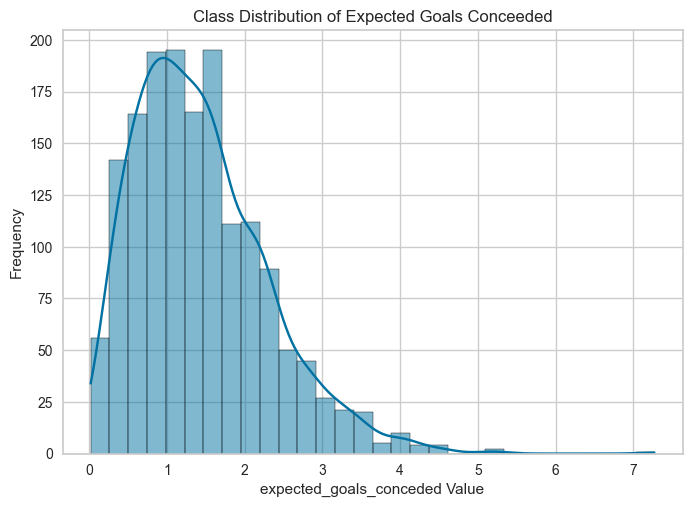

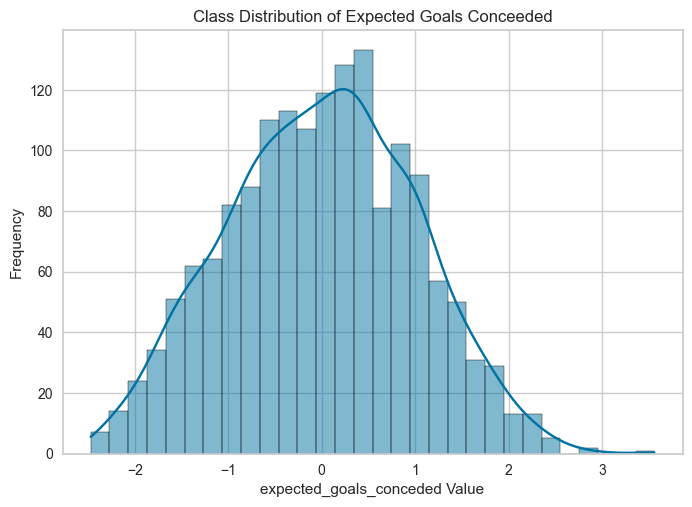

In [570]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_xgc.fit(g_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_gk_xgc, './models/pt_gk_xgc.pkl')  # Save fitted transformer

g_xgc_data['expected_goals_conceded'] = pt_gk_xgc.transform(g_xgc_data[['expected_goals_conceded']])


sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3016
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 65
[LightGBM] [Info] Start training from score -0.019876


,Description,Value
0,Session id,3892
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1612, 108)"
4,Transformed data shape,"(1612, 22)"
5,Transformed train set shape,"(1289, 22)"
6,Transformed test set shape,"(323, 22)"
7,Numeric features,106
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.7092,0.7698,0.8762,0.2150,0.4152,2.0094,1.5960
ridge,Ridge Regression,0.7097,0.7563,0.8687,0.2261,0.3977,1.9222,1.6720
lr,Linear Regression,0.7098,0.7568,0.8689,0.2256,0.3974,1.9267,1.2350
br,Bayesian Ridge,0.7132,0.7608,0.8714,0.2224,0.4023,1.8835,0.9280
et,Extra Trees Regressor,0.7194,0.7866,0.8857,0.1961,0.4191,1.9753,2.1710
rf,Random Forest Regressor,0.7213,0.7840,0.8843,0.2000,0.4205,2.0937,2.0350
ada,AdaBoost Regressor,0.7288,0.7968,0.8918,0.1912,0.4607,1.6369,1.1500
lightgbm,Light Gradient Boosting Machine,0.7293,0.8286,0.9088,0.1538,0.3975,2.2716,1.8280
lar,Least Angle Regression,0.7344,0.8190,0.9031,0.1659,0.3981,2.2562,1.3170
omp,Orthogonal Matching Pursuit,0.7358,0.8094,0.8989,0.1749,0.4214,1.8955,0.8610


GradientBoostingRegressor(random_state=3892)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


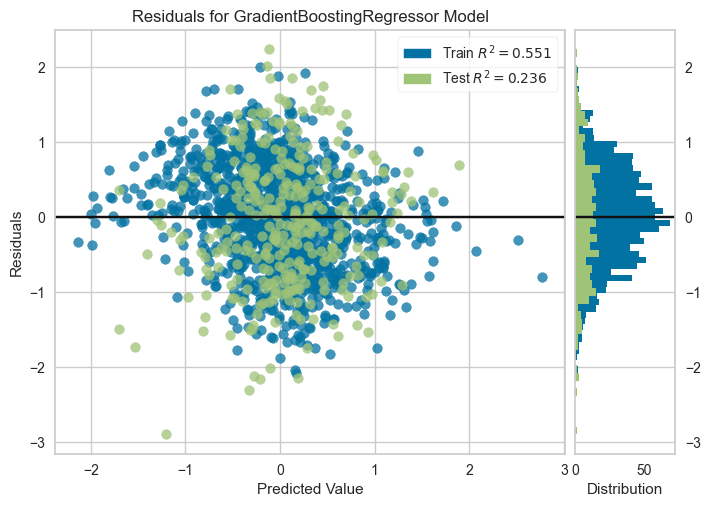

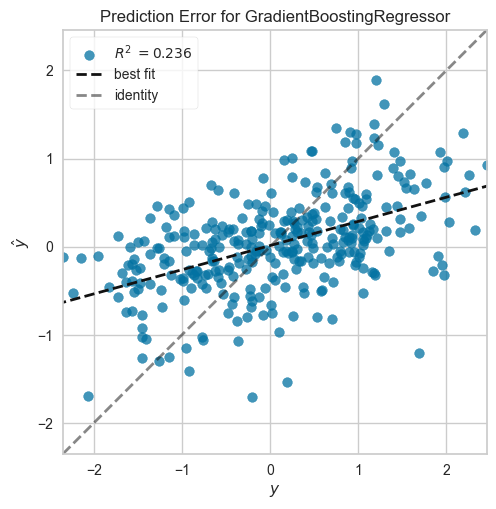

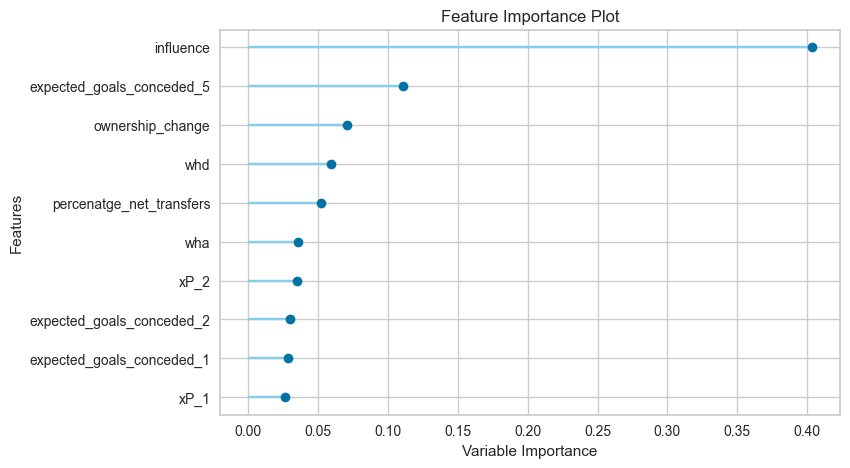

In [49]:
base_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Blended Model


In [50]:
blend_g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

g_xgc_best = compare_models(n_select=3, sort='MAE')
print(g_xgc_best)

print('Blended model')
# Ensemble (blend or stack)
g_xgc_blended = blend_models(g_xgc_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.473462 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2999
[LightGBM] [Info] Number of data points in the train set: 1289, number of used features: 64
[LightGBM] [Info] Start training from score -0.006745


,Description,Value
0,Session id,920
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1612, 108)"
4,Transformed data shape,"(1612, 22)"
5,Transformed train set shape,"(1289, 22)"
6,Transformed test set shape,"(323, 22)"
7,Numeric features,106
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.7057,0.7510,0.8655,0.2361,0.4061,1.8811,4.0870
rf,Random Forest Regressor,0.7101,0.7643,0.8729,0.2225,0.4142,1.9128,2.7610
ridge,Ridge Regression,0.7142,0.7607,0.8709,0.2271,0.4031,1.7949,1.6680
lr,Linear Regression,0.7145,0.7619,0.8716,0.2259,0.4028,1.7980,2.0790
br,Bayesian Ridge,0.7156,0.7624,0.8716,0.2264,0.4104,1.7846,1.3970
gbr,Gradient Boosting Regressor,0.7167,0.7638,0.8723,0.2234,0.4169,1.8757,0.8990
ada,AdaBoost Regressor,0.7275,0.7778,0.8803,0.2119,0.4481,1.7272,2.0050
omp,Orthogonal Matching Pursuit,0.7320,0.7972,0.8907,0.1926,0.4213,1.8296,2.7820
en,Elastic Net,0.7330,0.7985,0.8914,0.1917,0.4300,1.7437,2.4930
llar,Lasso Least Angle Regression,0.7353,0.8019,0.8934,0.1885,0.4393,1.6651,1.4830


[ExtraTreesRegressor(n_jobs=-1, random_state=920), RandomForestRegressor(n_jobs=-1, random_state=920), Ridge(random_state=920)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7237,0.7285,0.8535,0.3155,0.4107,1.1100
1,0.7775,0.9036,0.9506,0.1409,0.4586,1.5771
2,0.6757,0.6473,0.8046,0.2686,0.3754,1.2551
3,0.6357,0.6208,0.7879,0.3298,0.3771,1.7785
4,0.7180,0.7788,0.8825,0.3365,0.4362,1.5270
5,0.6592,0.7063,0.8404,0.2464,0.4090,1.8913
6,0.6740,0.6781,0.8235,0.1150,0.3635,3.2220
7,0.7132,0.7729,0.8791,0.2829,0.4177,1.7633
8,0.7206,0.7366,0.8582,0.2167,0.4233,1.0917


### Save Model


In [51]:
g_xgc_final_model = finalize_model(g_xgc_blended)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                  TransformerWrapper(exclude=[],
                                     transformer=SelectFromModel(estimator=LGBMRegressor()

## Def


expected_goals_conceded
0.00    79
0.83    75
1.03    57
1.48    56
1.08    47
        ..
9.84     1
6.86     1
6.94     1
3.06     1
3.07     1
Name: count, Length: 386, dtype: int64


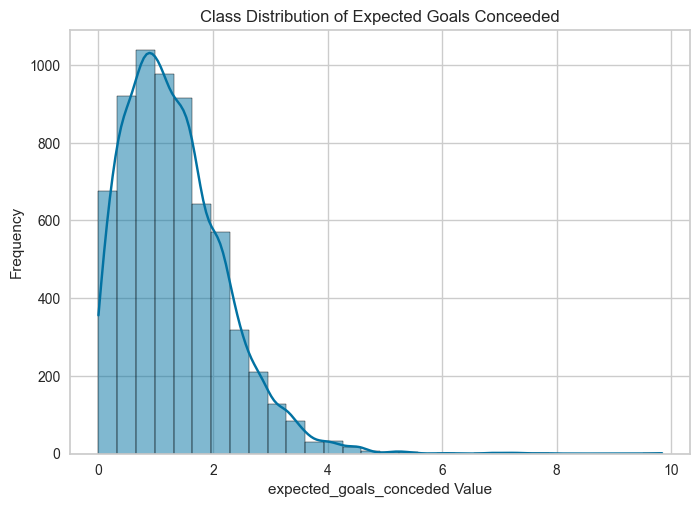

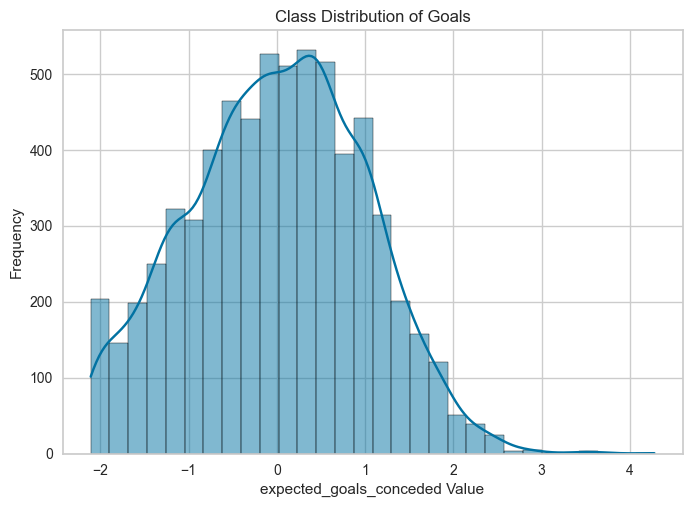

In [571]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xgc.fit(def_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_def_xgc, './models/pt_def_xgc.pkl')  # Save fitted transformer

def_xgc_data['expected_goals_conceded'] = pt_def_xgc.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.079809 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6298
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 72
[LightGBM] [Info] Start training from score 0.009489


,Description,Value
0,Session id,4087
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6573, 108)"
4,Transformed data shape,"(6573, 22)"
5,Transformed train set shape,"(5258, 22)"
6,Transformed test set shape,"(1315, 22)"
7,Numeric features,106
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.6388,0.6453,0.8017,0.3570,0.3856,1.9067,5.6570
lightgbm,Light Gradient Boosting Machine,0.6671,0.6918,0.8313,0.3097,0.3965,2.0046,2.2550
rf,Random Forest Regressor,0.6744,0.7101,0.8420,0.2917,0.4081,1.8241,10.1280
xgboost,Extreme Gradient Boosting,0.6768,0.7236,0.8503,0.2778,0.3821,2.2178,1.8090
gbr,Gradient Boosting Regressor,0.6945,0.7375,0.8583,0.2640,0.4205,1.7891,2.8350
ada,AdaBoost Regressor,0.7525,0.8459,0.9195,0.1558,0.4818,1.4957,2.3960
lr,Linear Regression,0.7640,0.8792,0.9374,0.1227,0.4548,1.8490,1.1030
ridge,Ridge Regression,0.7642,0.8796,0.9376,0.1224,0.4550,1.8477,1.6600
br,Bayesian Ridge,0.7659,0.8818,0.9387,0.1202,0.4584,1.8293,1.5810
omp,Orthogonal Matching Pursuit,0.8019,0.9578,0.9783,0.0449,0.5168,1.4351,1.2010


ExtraTreesRegressor(n_jobs=-1, random_state=4087)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


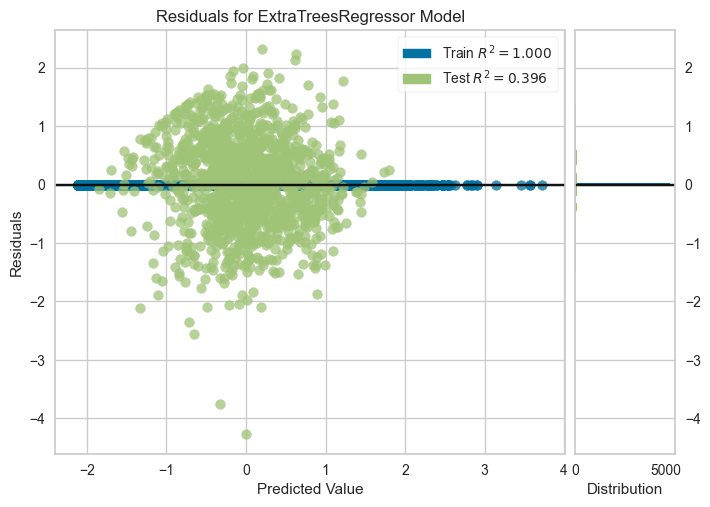

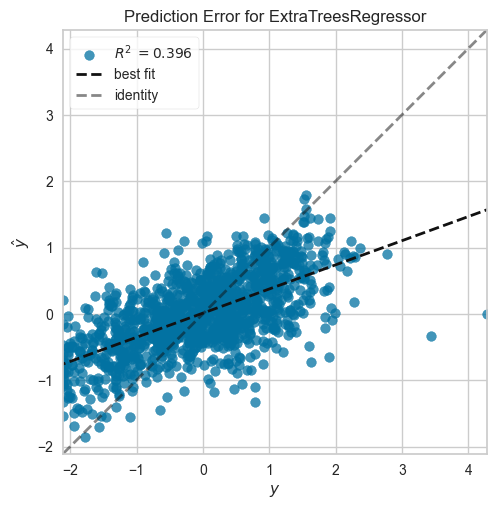

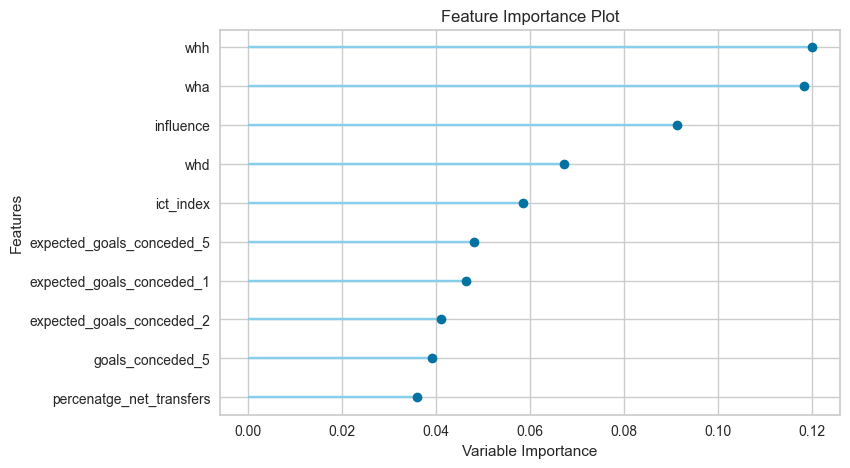

In [53]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Blended Model


In [54]:
blend_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xgc_best = compare_models(n_select=3, sort='MAE')
print(def_xgc_best)

print('Blended model')
# Ensemble (blend or stack)
def_xgc_blended = blend_models(def_xgc_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6543
[LightGBM] [Info] Number of data points in the train set: 5258, number of used features: 72
[LightGBM] [Info] Start training from score -0.012182


,Description,Value
0,Session id,5063
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6573, 108)"
4,Transformed data shape,"(6573, 22)"
5,Transformed train set shape,"(5258, 22)"
6,Transformed test set shape,"(1315, 22)"
7,Numeric features,106
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.6355,0.6409,0.7989,0.3566,0.3853,1.6808,3.3840
lightgbm,Light Gradient Boosting Machine,0.6656,0.6937,0.8320,0.3042,0.3938,1.9390,2.1280
rf,Random Forest Regressor,0.6712,0.7009,0.8360,0.2970,0.4055,1.6665,6.3600
xgboost,Extreme Gradient Boosting,0.6785,0.7334,0.8557,0.2631,0.3802,2.0993,1.9720
gbr,Gradient Boosting Regressor,0.6997,0.7484,0.8644,0.2492,0.4241,1.6637,2.0230
ada,AdaBoost Regressor,0.7628,0.8708,0.9327,0.1265,0.4979,1.4565,1.8580
ridge,Ridge Regression,0.7672,0.8845,0.9401,0.1125,0.4583,1.8055,2.9050
lr,Linear Regression,0.7673,0.8851,0.9405,0.1119,0.4581,1.8097,1.7940
br,Bayesian Ridge,0.7695,0.8874,0.9417,0.1095,0.4626,1.7725,2.3360
en,Elastic Net,0.8001,0.9536,0.9761,0.0437,0.5302,1.3473,3.4770


[ExtraTreesRegressor(n_jobs=-1, random_state=5063), LGBMRegressor(n_jobs=-1, random_state=5063), RandomForestRegressor(n_jobs=-1, random_state=5063)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6066,0.6195,0.7871,0.3359,0.3739,1.4130
1,0.6320,0.6232,0.7895,0.3929,0.3808,1.1573
2,0.6747,0.6814,0.8255,0.2775,0.4101,1.3620
3,0.7301,0.8116,0.9009,0.1915,0.4395,1.7740
4,0.6530,0.6965,0.8346,0.3607,0.3974,1.6206
5,0.6261,0.6121,0.7824,0.3619,0.3842,3.0156
6,0.6503,0.6575,0.8108,0.3983,0.3947,1.2818
7,0.6933,0.7594,0.8714,0.2650,0.4354,1.5878
8,0.6153,0.5613,0.7492,0.3921,0.3673,2.0840


In [55]:
tuned_blend = tune_model(def_xgc_blended, optimize='MAE', n_iter=10)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6025,0.6113,0.7818,0.3447,0.3726,1.3999
1,0.6239,0.6077,0.7796,0.4080,0.3757,1.1498
2,0.6743,0.6785,0.8237,0.2806,0.4099,1.4230
3,0.7281,0.8057,0.8976,0.1973,0.4388,1.7593
4,0.6461,0.6844,0.8273,0.3718,0.3948,1.6768
5,0.6186,0.5996,0.7743,0.3750,0.3793,3.0776
6,0.6399,0.6407,0.8004,0.4137,0.3856,1.2866
7,0.6907,0.7565,0.8698,0.2678,0.4350,1.5422
8,0.6083,0.5515,0.7426,0.4028,0.3614,2.0930


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [56]:
def_xgc_final_model = finalize_model(tuned_blend)
save_model(def_xgc_final_model, './models/def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                                                 max_features=21,
                                                         